# 01 · Exploratory analysis

**Question:** did the email campaign work, and is there any sign that it worked *differently* for different customers?

This notebook covers the basics before any modelling: treatment balance, outcome rates per arm, the average treatment effect (ATE) with a confidence interval, and a small subgroup preview that motivates uplift modelling.

**Framing (agreed for the core project):** treatment = received *any* email (men's or women's) vs no email; outcome = `conversion`, with `visit` as a robustness check. The three-arm split is kept for the multi-treatment extension at the end of the project.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from uplift.data import load_hillstrom, make_uplift_frame
from uplift.eda import ate_bootstrap_ci, ate_wald_ci, standardised_mean_differences
from uplift.plotting import CONTROL, MUTED, TREATED, apply_style

apply_style()
df = load_hillstrom()
X, y, w = make_uplift_frame(df, "conversion")
print(f"{len(df):,} customers, {df.shape[1]} columns, {df.isna().sum().sum()} missing values")
df.head()

64,000 customers, 12 columns, 0 missing values


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 1. Treatment balance

In a randomised experiment, the emailed and control groups should look alike *before* the email. If they do, any difference in outcomes can be put down to the email. Two checks: group sizes, and the standardised mean difference (SMD) for each feature. Below 0.1 is conventionally treated as balanced.

,customers,share
segment,,
Womens E-Mail,21387,0.334
Mens E-Mail,21307,0.333
No E-Mail,21306,0.333


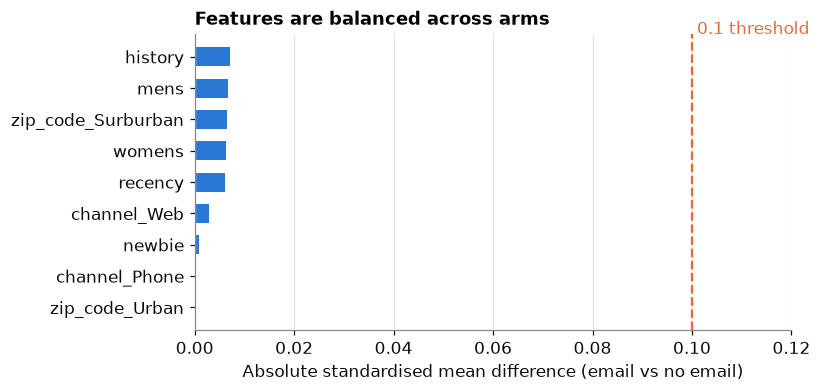

Largest SMD: 0.007


In [2]:
arms = df["segment"].value_counts().rename("customers").to_frame()
arms["share"] = (arms["customers"] / len(df)).round(3)
display(arms)

smd = standardised_mean_differences(X, w).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(smd.index, smd.values, color=TREATED, height=0.6)
ax.axvline(0.1, color=CONTROL, linestyle="--", linewidth=1.5)
ax.text(0.1, len(smd) - 0.4, " 0.1 threshold", color=CONTROL, va="bottom")
ax.set_xlim(0, 0.12)
ax.set_xlabel("Absolute standardised mean difference (email vs no email)")
ax.set_title("Features are balanced across arms")
ax.grid(axis="y", visible=False)
plt.show()
print(f"Largest SMD: {smd.max():.3f}")

## 2. Outcome rates per arm

,visit,conversion,spend
segment,,,
No E-Mail,0.1062,0.0057,0.6528
Mens E-Mail,0.1828,0.0125,1.4226
Womens E-Mail,0.1514,0.0088,1.0772


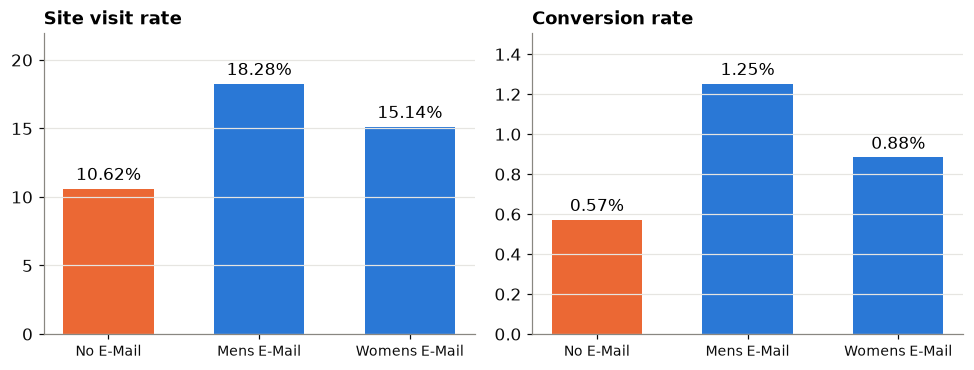

In [3]:
rates = df.groupby("segment")[["visit", "conversion", "spend"]].mean()
rates = rates.loc[["No E-Mail", "Mens E-Mail", "Womens E-Mail"]]
display(rates.round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
colours = [CONTROL, TREATED, TREATED]
for ax, col, title in zip(
    axes, ["visit", "conversion"], ["Site visit rate", "Conversion rate"], strict=True
):
    vals = rates[col] * 100
    bars = ax.bar(rates.index, vals, color=colours, width=0.6)
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.set_title(title)
    ax.set_ylim(0, vals.max() * 1.2)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

## 3. Average treatment effect with a confidence interval

Because assignment was random, the ATE is simply the difference in mean outcomes between the emailed and control groups. The **headline interval is the Wald (normal-approximation) interval**. As a check that the normality assumption is harmless here, we compare it with a **bootstrap** interval.

In [4]:
rows = []
for outcome in ["conversion", "visit"]:
    _, y_o, w_o = make_uplift_frame(df, outcome)
    res = ate_wald_ci(y_o, w_o)
    boot_lo, boot_hi = ate_bootstrap_ci(y_o, w_o)
    rows.append(
        {
            "outcome": outcome,
            "control rate %": res.mean_control * 100,
            "email rate %": res.mean_treated * 100,
            "ATE (pp)": res.ate * 100,
            "Wald 95% CI (pp)": f"[{res.lower * 100:.2f}, {res.upper * 100:.2f}]",
            "bootstrap 95% CI (pp)": f"[{boot_lo * 100:.2f}, {boot_hi * 100:.2f}]",
            "relative lift %": res.relative_lift * 100,
        }
    )
ate_table = pd.DataFrame(rows).set_index("outcome").round(2)
ate_table

,control rate %,email rate %,ATE (pp),Wald 95% CI (pp),bootstrap 95% CI (pp),relative lift %
outcome,,,,,,
conversion,0.57,1.07,0.50,"[0.35, 0.64]","[0.35, 0.64]",86.53
visit,10.62,16.70,6.09,"[5.54, 6.63]","[5.55, 6.62]",57.35


## 4. Subgroup preview: does the effect vary?

The ATE is one number for everyone. If the email worked equally well for every customer, there would be nothing to model. Here the conversion effect is estimated separately within a few simple customer groups (each with its own 95% interval). If the intervals differ, targeting is worth doing.

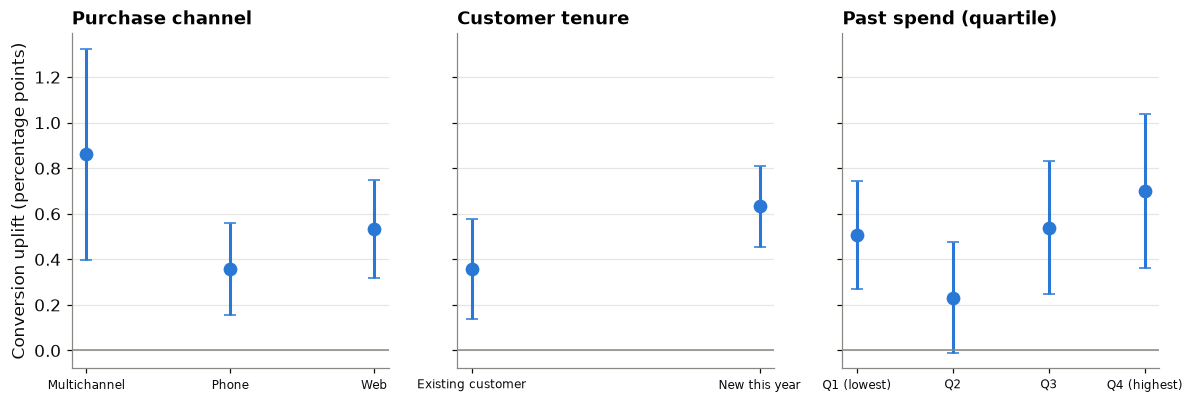

In [5]:
def subgroup_ates(frame: pd.DataFrame, by: str) -> pd.DataFrame:
    out = []
    for level, part in frame.groupby(by, observed=True):
        res = ate_wald_ci(part["conversion"], (part["segment"] != "No E-Mail").astype(int))
        out.append(
            {
                "group": str(level),
                "ate": res.ate * 100,
                "err_lo": (res.ate - res.lower) * 100,
                "err_hi": (res.upper - res.ate) * 100,
                "n": len(part),
            }
        )
    return pd.DataFrame(out)


frame = df.assign(
    newbie=df["newbie"].map({0: "Existing customer", 1: "New this year"}),
    spend_band=pd.qcut(df["history"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]),
)
panels = [
    ("channel", "Purchase channel"),
    ("newbie", "Customer tenure"),
    ("spend_band", "Past spend (quartile)"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
for ax, (col, title) in zip(axes, panels, strict=True):
    s = subgroup_ates(frame, col)
    ax.errorbar(
        s["group"],
        s["ate"],
        yerr=[s["err_lo"], s["err_hi"]],
        fmt="o",
        color=TREATED,
        ecolor=TREATED,
        elinewidth=2,
        capsize=4,
        markersize=8,
    )
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Conversion uplift (percentage points)")
plt.tight_layout()
plt.show()

## 5. What this means

**Findings**

- **Randomisation worked.** The arms are the same size (about a third each) and every feature has an SMD below 0.01, far under the 0.1 rule of thumb. The raw difference in outcomes is therefore a fair estimate of the causal effect.
- **The email works on average.** Conversion rises from 0.57% to 1.07%, an ATE of **+0.50 percentage points (95% CI 0.35 to 0.64)**, a relative lift of about 87%. The bootstrap interval is identical to two decimal places, so the normal approximation is fine here. The visit outcome tells the same story (+6.1 pp), so the conclusion does not hinge on the sparse conversion outcome.
- **The effect may vary, but the evidence is suggestive, not conclusive.** Point estimates range from about 0.2 pp (second spend quartile) to about 0.9 pp (multichannel buyers), and new customers respond more than existing ones (0.63 vs 0.36 pp). However, most intervals overlap, and these are one-variable-at-a-time comparisons that ignore combinations of features (and I looked at several, so some spread is expected by chance). This is exactly the gap an uplift model fills: it combines all features to rank customers, and the test set tells us honestly whether that ranking beats random.

**Why this matters for targeting.** A +0.5 pp average effect on a 0.57% base rate is small in absolute terms. Emailing everyone costs money on the ~99% who would never buy, and on customers who would have bought anyway. The commercial question is therefore not "does the email work?" but "can we find the customers where it works well enough to cover its cost?"

**Caveats to carry forward.** Conversions are rare: only about 580 in the whole dataset, so a 30% test set holds just ~175 (roughly 37 control and 137 emailed), so evaluation metrics will be noisy, which is why the later phases add repeated splits. Hillstrom is a 2008 dataset from a single retailer, so treat the business figures as an illustration of the method, not a forecast.